In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

DATA_DIR  = "../outputs/datasets/"
MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

TARGETS = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss",
}

EXCLUDE = ["StartDateTime","EndDateTime","Perf_Filename","ND_Filename","RunDateTime"]

WINDOW_SIZE = 5
BATCH_SIZE  = 32
EPOCHS      = 60
LR          = 1e-3


# ============================================================
# Load dataset
# ============================================================

def load_split_data():
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test

def extract_xy(df):

    # Always define targets here (ensures no notebook corruption)
    target_map = {
        "Throughput": "Perf_Avg_Throughput",
        "Latency":    "Perf_Avg_Latency",
        "Loss":       "Perf_Avg_Loss",
    }

    # Remove unwanted columns
    df = df.drop(columns=[c for c in EXCLUDE if c in df.columns], errors="ignore")

    # Numeric-only
    df_num = df.select_dtypes(include=[np.number])

    # Target column names
    target_cols = list(target_map.values())

    # Feature columns
    feature_cols = [c for c in df_num.columns if c not in target_cols]

    # Features
    X = df_num[feature_cols].fillna(0).values.astype(np.float32)

    # Target dict
    y = {
        "Throughput": df_num[target_map["Throughput"]].fillna(0).values.astype(np.float32),
        "Latency":    df_num[target_map["Latency"]].fillna(0).values.astype(np.float32),
        "Loss":       df_num[target_map["Loss"]].fillna(0).values.astype(np.float32),
    }

    return X, y, feature_cols



# ============================================================
# Create sequence windows
# ============================================================

def make_sequence_dataset(X, y, window=1):

    N = len(X)

    # If dataset is empty → return empty arrays
    if N == 0:
        return np.empty((0, 1, X.shape[1])), np.empty((0,))

    # Always reshape rows individually into sequences
    # Each row = 1-step sequence
    X_seq = X.reshape(N, 1, X.shape[1])
    y_seq = y.copy()

    return X_seq, y_seq





# ============================================================
# LSTM Model
# ============================================================

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


# ============================================================
# Train a single LSTM model
# ============================================================

def train_single_lstm(X_train, y_train, X_valid, y_valid, model_name, input_dim):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = LSTMModel(input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1))
    valid_ds = TensorDataset(torch.tensor(X_valid), torch.tensor(y_valid).unsqueeze(1))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)

    best_loss = float("inf")
    patience, patience_limit = 0, 10

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                valid_loss += loss_fn(pred, yb).item()

        valid_loss /= len(valid_loader)

        print(f"Epoch {epoch+1}/{EPOCHS} | Train={train_loss:.4f}, Valid={valid_loss:.4f}")

        if valid_loss < best_loss:
            best_loss = valid_loss
            best_state = model.state_dict()
            patience = 0
        else:
            patience += 1
            if patience >= patience_limit:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    model_path = os.path.join(MODEL_DIR, f"lstm_model_{model_name.lower()}.pt")
    torch.save(model.state_dict(), model_path)
    print(f"Saved → {model_path}")

    return model


# ============================================================
# Prediction only
# ============================================================

def predict_lstm(model, X):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X).to(device)).cpu().numpy().flatten()
    return preds


# ============================================================
# TRAIN PIPELINE (TRAIN + SAVE PREDICTIONS ONLY)
# ============================================================

def train_lstm_pipeline():

    df_train, df_valid, df_test = load_split_data()

    X_train, y_train_dict, feature_cols = extract_xy(df_train)
    X_valid, y_valid_dict, _           = extract_xy(df_valid)
    X_test,  y_test_dict, _            = extract_xy(df_test)

    input_dim = X_train.shape[1]
    print(f"LSTM Input dimension = {input_dim}")

    for target_name in TARGETS.keys():

        print(f"\n===== Training LSTM for {target_name} =====")

        y_train = y_train_dict[target_name]
        y_valid = y_valid_dict[target_name]
        y_test  = y_test_dict[target_name]

        Xtr, ytr = make_sequence_dataset(X_train, y_train, WINDOW_SIZE)
        Xva, yva = make_sequence_dataset(X_valid, y_valid, WINDOW_SIZE)
        Xte, yte = make_sequence_dataset(X_test,  y_test,  WINDOW_SIZE)

        model = train_single_lstm(Xtr, ytr, Xva, yva, target_name, input_dim)

        pred_valid = predict_lstm(model, Xva)
        pred_test  = predict_lstm(model, Xte)

        pd.DataFrame({"y_true": yva, "y_pred": pred_valid}).to_csv(
            os.path.join(PRED_DIR, f"lstm_{target_name}_valid_predictions.csv"),
            index=False
        )
        pd.DataFrame({"y_true": yte, "y_pred": pred_test}).to_csv(
            os.path.join(PRED_DIR, f"lstm_{target_name}_test_predictions.csv"),
            index=False
        )

        print(f"Saved predictions for {target_name}")


In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/"
os.makedirs(PLOT_DIR, exist_ok=True)

# TARGETS = ["Throughput", "Latency", "Loss"]
TARGETS = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss",
}

plt.style.use("seaborn-v0_8-whitegrid")


def load_preds(metric, split):
    path = os.path.join(PRED_DIR, f"lstm_{metric}_{split}_predictions.csv")
    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


def plot_pred_vs_actual(y_true, y_pred, title, outfile, showImage=False):
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)

    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=2)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    print(f"Saved → {outfile}")

    if showImage:
        plt.show()
    else:
        plt.close()


# ============================================================
# Plot Time Series
# ============================================================

def plot_time_series(y_true, y_pred, title, outfile, showImage=False):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true.values, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linewidth=2, linestyle="--")

    plt.legend()
    plt.title(title)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    print(f"Saved → {outfile}")

    if showImage:
        plt.show()
    else:
        plt.close()


# ============================================================
# Generate All LSTM Plots
# ============================================================

def generate_lstm_plots(showImage=False):

    for metric in TARGETS:

        print(f"\n=== Generating LSTM plots for {metric} ===")

        # Validation
        yv, pv = load_preds(metric, "valid")
        plot_pred_vs_actual(
            yv, pv,
            title=f"LSTM – Predicted vs Actual ({metric}, Valid)",
            outfile=os.path.join(PLOT_DIR, f"lstm_{metric}_pred_valid.png"),
            showImage=showImage
        )
        plot_time_series(
            yv, pv,
            title=f"LSTM – Time Series ({metric}, Valid)",
            outfile=os.path.join(PLOT_DIR, f"lstm_{metric}_ts_valid.png"),
            showImage=showImage
        )

        # Test
        yt, pt = load_preds(metric, "test")
        plot_pred_vs_actual(
            yt, pt,
            title=f"LSTM – Predicted vs Actual ({metric}, Test)",
            outfile=os.path.join(PLOT_DIR, f"lstm_{metric}_pred_test.png"),
            showImage=showImage
        )
        plot_time_series(
            yt, pt,
            title=f"LSTM – Time Series ({metric}, Test)",
            outfile=os.path.join(PLOT_DIR, f"lstm_{metric}_ts_test.png"),
            showImage=showImage
        )

    print("\nAll LSTM plots generated successfully!")


In [43]:
# from lstm_training import train_lstm_pipeline
train_lstm_pipeline()


LSTM Input dimension = 103

===== Training LSTM for Throughput =====
Epoch 1/60 | Train=0.2201, Valid=0.1575
Epoch 2/60 | Train=0.2035, Valid=0.1478
Epoch 3/60 | Train=0.1903, Valid=0.1384
Epoch 4/60 | Train=0.1795, Valid=0.1294
Epoch 5/60 | Train=0.1690, Valid=0.1206
Epoch 6/60 | Train=0.1586, Valid=0.1122
Epoch 7/60 | Train=0.1480, Valid=0.1037
Epoch 8/60 | Train=0.1374, Valid=0.0943
Epoch 9/60 | Train=0.1249, Valid=0.0865
Epoch 10/60 | Train=0.1154, Valid=0.0791
Epoch 11/60 | Train=0.1064, Valid=0.0718
Epoch 12/60 | Train=0.0977, Valid=0.0636
Epoch 13/60 | Train=0.0892, Valid=0.0546
Epoch 14/60 | Train=0.0795, Valid=0.0481
Epoch 15/60 | Train=0.0717, Valid=0.0407
Epoch 16/60 | Train=0.0641, Valid=0.0351
Epoch 17/60 | Train=0.0570, Valid=0.0298
Epoch 18/60 | Train=0.0501, Valid=0.0249
Epoch 19/60 | Train=0.0437, Valid=0.0205
Epoch 20/60 | Train=0.0377, Valid=0.0163
Epoch 21/60 | Train=0.0321, Valid=0.0122
Epoch 22/60 | Train=0.0269, Valid=0.0091
Epoch 23/60 | Train=0.0222, Valid=0.00


=== Generating LSTM plots for Throughput ===
Saved → ../outputs/models/plots/lstm_Throughput_pred_valid.png


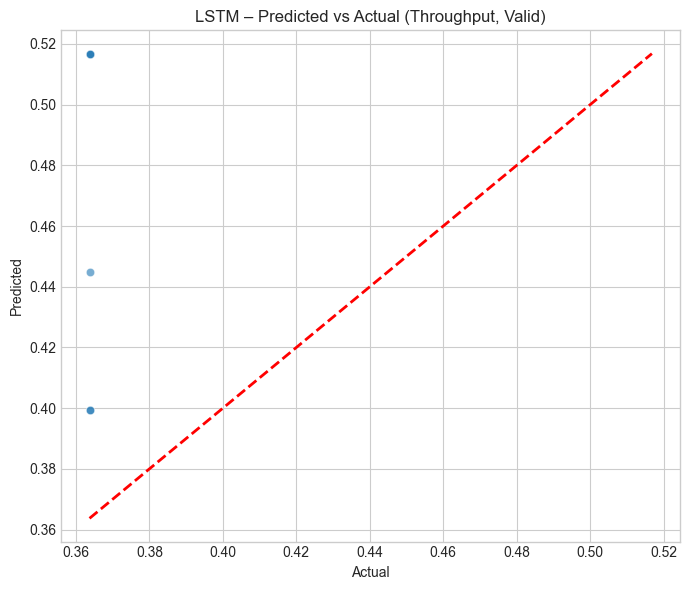

Saved → ../outputs/models/plots/lstm_Throughput_ts_valid.png


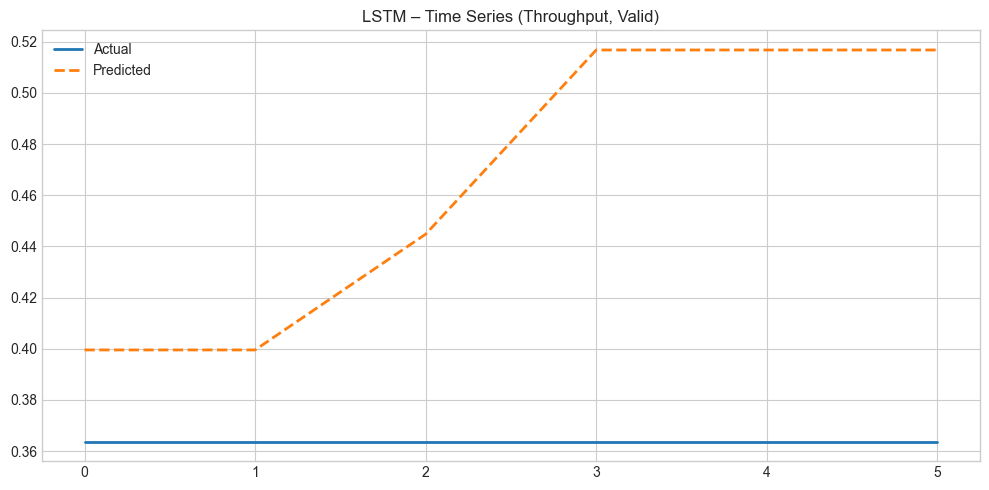

Saved → ../outputs/models/plots/lstm_Throughput_pred_test.png


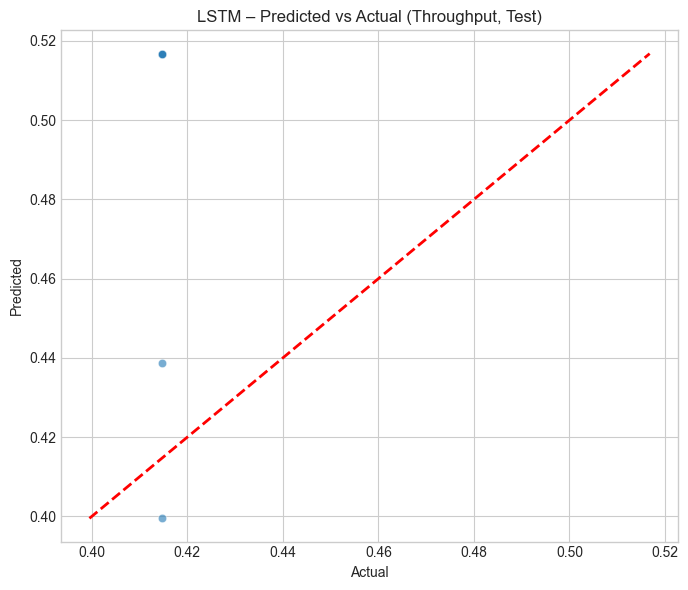

Saved → ../outputs/models/plots/lstm_Throughput_ts_test.png


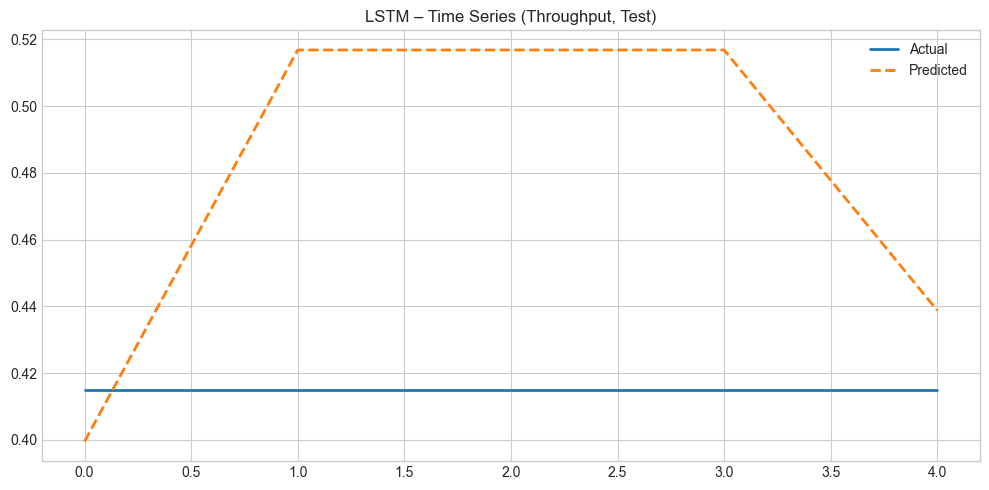


=== Generating LSTM plots for Latency ===
Saved → ../outputs/models/plots/lstm_Latency_pred_valid.png


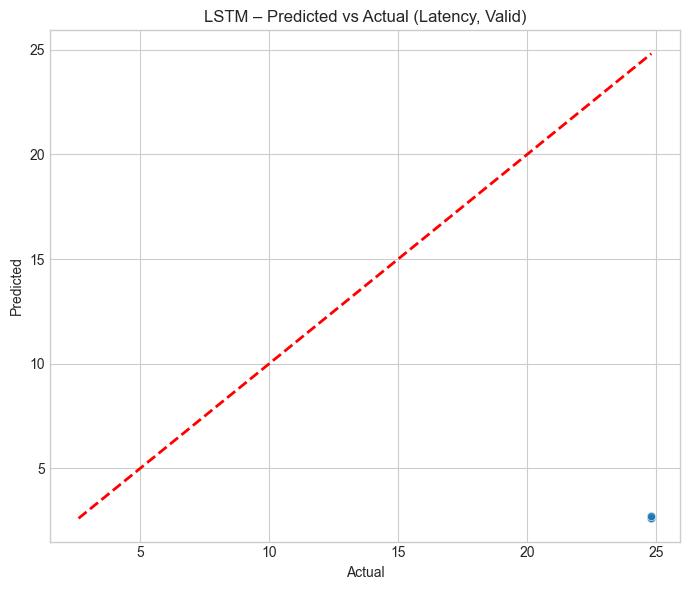

Saved → ../outputs/models/plots/lstm_Latency_ts_valid.png


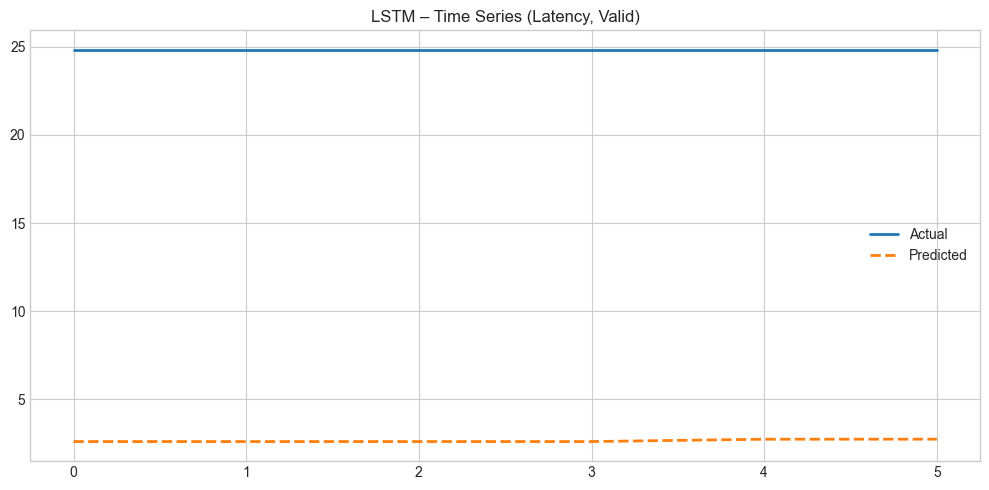

Saved → ../outputs/models/plots/lstm_Latency_pred_test.png


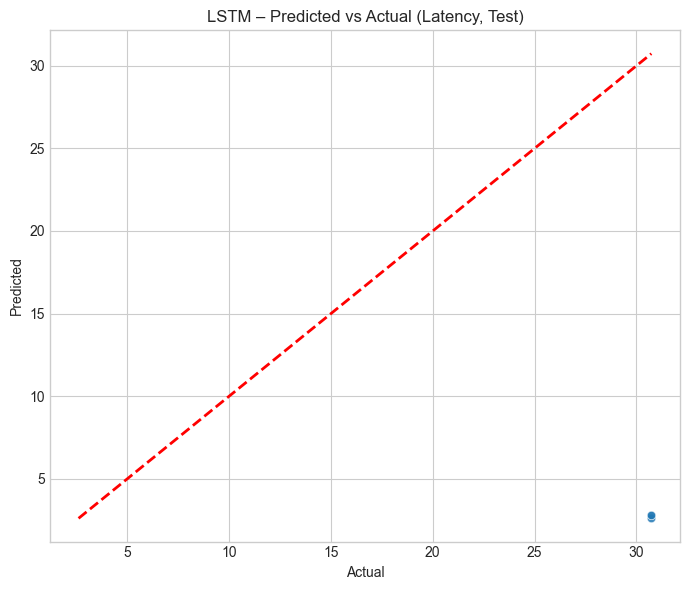

Saved → ../outputs/models/plots/lstm_Latency_ts_test.png


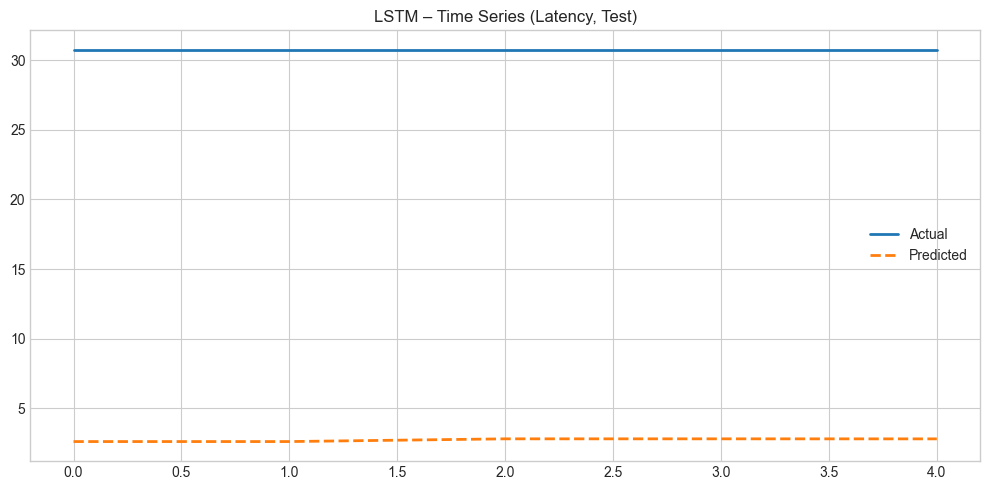


=== Generating LSTM plots for Loss ===
Saved → ../outputs/models/plots/lstm_Loss_pred_valid.png


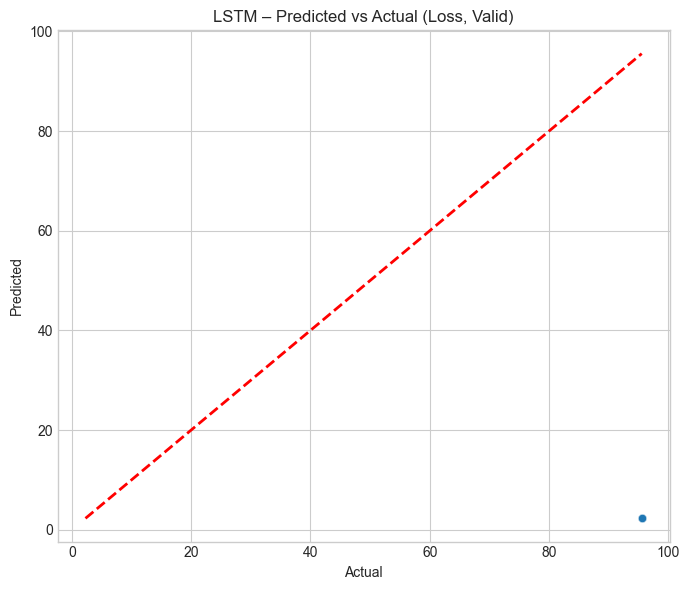

Saved → ../outputs/models/plots/lstm_Loss_ts_valid.png


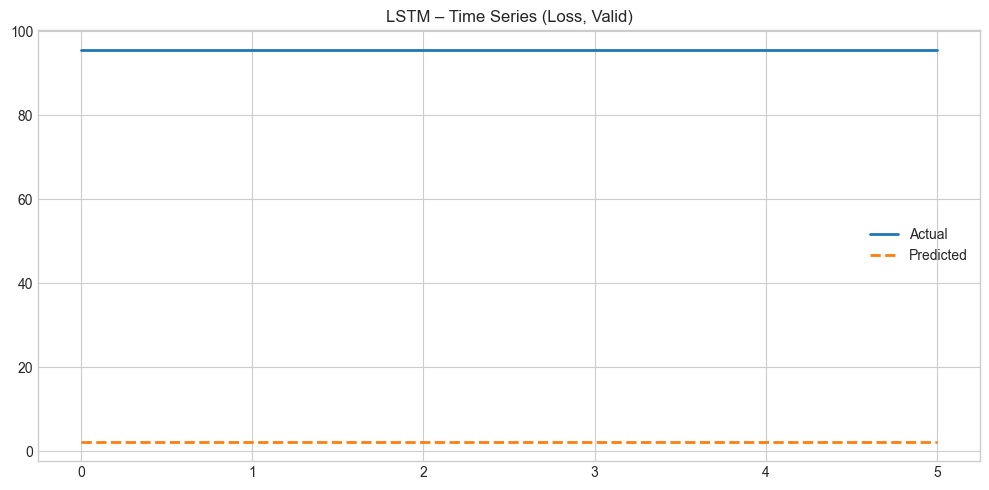

Saved → ../outputs/models/plots/lstm_Loss_pred_test.png


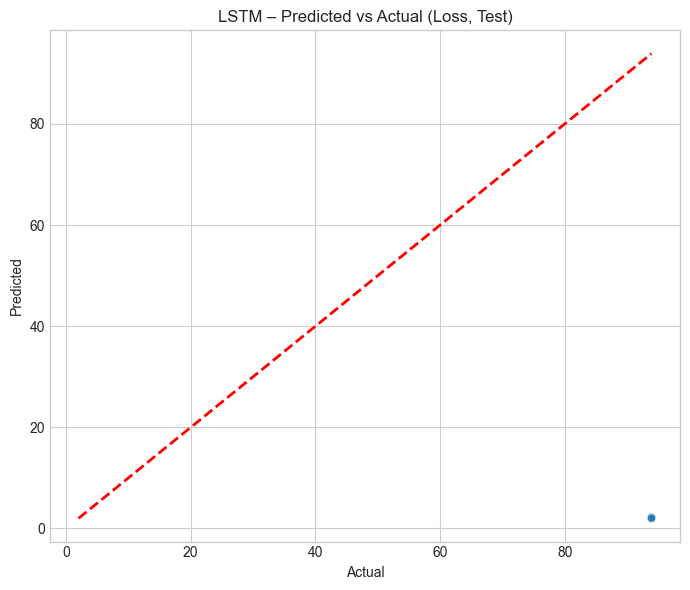

Saved → ../outputs/models/plots/lstm_Loss_ts_test.png


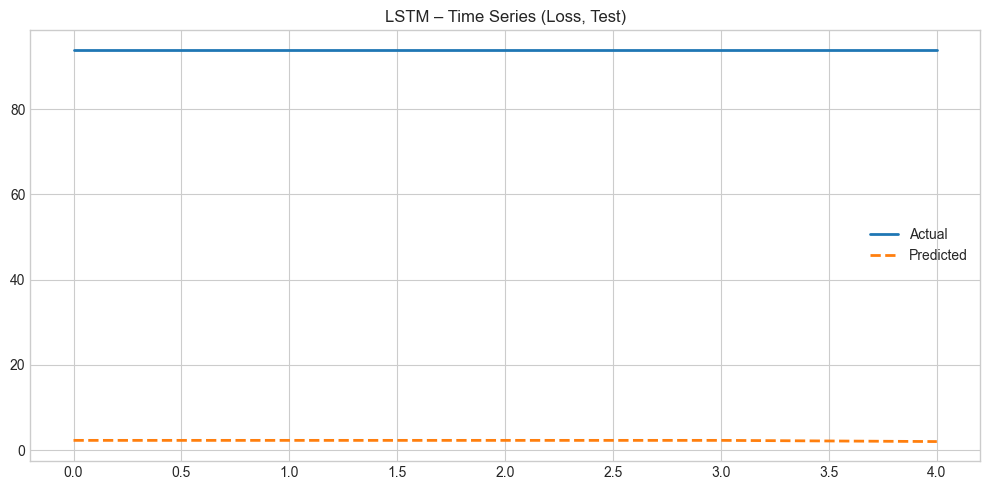


All LSTM plots generated successfully!


In [44]:
# from lstm_plots import generate_lstm_plots
generate_lstm_plots(showImage=True)



In [46]:
import os
import time
import numpy as np
import torch
import torch.nn as nn


# ============================================================
# 1. Define LSTM model (must match training architecture)
# ============================================================

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.fc(output[:, -1, :])  # last timestep
        

# ============================================================
# 2. Load model from .pt file
# ============================================================

def load_lstm_model(model_path, input_dim):
    model = LSTMModel(input_dim)
    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model


# ============================================================
# 3. Count parameters & model size
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def model_size_bytes(model):
    """
    FP32 weights → 4 bytes per parameter
    """
    return count_parameters(model) * 4


# ============================================================
# 4. FLOPs estimation for LSTM
# ============================================================

def compute_lstm_flops(model, sequence_len=1):
    """
    FLOPs for stacked LSTM + final FC layer.

    LSTM FLOPs per cell:
      FLOPs = 4 * H * (H + I + 1)
    (4 gates: input, forget, output, candidate)

    For L layers and L_seq timesteps:
      Total = layers * timesteps * FLOPs_cell

    FC FLOPs = 2 * H * 1
    """

    I = model.input_dim
    H = model.hidden_dim
    L = model.num_layers

    # FLOPs for one LSTM cell
    flops_cell = 4 * H * (H + I + 1)

    # Total for all layers * timesteps
    flops_lstm = L * sequence_len * flops_cell

    # Final FC
    flops_fc = 2 * H * 1

    return flops_lstm + flops_fc


# ============================================================
# 5. Measure inference latency
# ============================================================

def measure_latency(model, example_input, runs=200, warmup=20):
    device = "cpu"
    model.to(device)
    example_input = example_input.to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(example_input)

    # Timed runs
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(runs):
            _ = model(example_input)
    t1 = time.perf_counter()

    return (t1 - t0) / runs


# ============================================================
# 6. Energy estimation
# ============================================================

def estimate_energy(latency_s, power_W=2.0):
    """
    E = P × t
    """
    return latency_s * power_W


# ============================================================
# 7. Peak activation memory
# ============================================================

def estimate_peak_activation_memory(model, example_input):
    with torch.no_grad():
        output = model(example_input)
    return output.numel() * 4  # FP32


# ============================================================
# 8. Full evaluation function
# ============================================================

def evaluate_lstm_edge(model_path, input_dim, sequence_len=1, assumed_power_W=2.0):
    
    # ---------------- Load Model ----------------
    model = load_lstm_model(model_path, input_dim)

    # Input tensor for evaluation
    example_input = torch.randn(1, sequence_len, input_dim)

    # ---------------- Compute Metrics ----------------
    params = count_parameters(model)
    size_b = model_size_bytes(model)
    size_mb = size_b / (1024 * 1024)

    flops = compute_lstm_flops(model, sequence_len)
    latency_s = measure_latency(model, example_input)
    latency_ms = latency_s * 1000

    energy = estimate_energy(latency_s, assumed_power_W)
    peak_mem = estimate_peak_activation_memory(model, example_input)

    # ---------------- Package Output ----------------
    return {
        "Model Path": model_path,
        "Parameters": params,
        "Model Size (Bytes)": size_b,
        "Model Size (MB)": size_mb,
        "FLOPs": flops,
        "Latency (s)": latency_s,
        "Latency (ms)": latency_ms,
        "Energy Estimated (J)": energy,
        "Peak Activation Memory (Bytes)": peak_mem
    }



In [47]:
# from lstm_edge_evaluation import evaluate_lstm_edge

model_path = "../outputs/models/lstm_model_throughput.pt"
input_dim = 103   # number of features
sequence_len = 1  # because your dataset uses WINDOW_SIZE=1

metrics = evaluate_lstm_edge(
    model_path=model_path,
    input_dim=input_dim,
    sequence_len=sequence_len
)

for k, v in metrics.items():
    print(f"{k}: {v}")


Model Path: ../outputs/models/lstm_model_throughput.pt
Parameters: 76609
Model Size (Bytes): 306436
Model Size (MB): 0.2922401428222656
FLOPs: 86144
Latency (s): 0.0006123690004460514
Latency (ms): 0.6123690004460514
Energy Estimated (J): 0.0012247380008921028
Peak Activation Memory (Bytes): 4
